# GLMsingle Analysis — DNumRisk

## Imports

In [1]:
from glmsingle.glmsingle import GLM_single
import argparse
import os
import os.path as op
from nilearn import image
from numrisk.utils.data import Subject
from nilearn.glm.first_level import make_first_level_design_matrix
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# GLMdenois does not work without noise voxels! -- space = fsaverage5 does not make sense!

# run in terminal (weird numba error, which does not happen in VS-notebook):
# rm -rf ~/.numba_cache
# export NUMBA_DISABLE_JIT=1

# check: https://github.com/cvnlab/GLMsingle/blob/main/glmsingle/glmsingle.py

TR = 2.827 # that was wrong, and then design_matrix was weirdly of (but hard to figure out, random early volumes had multiple ones)
stim_duration = 0.6

## Parameters

In [2]:
subject     = '01'
session     = 1
runs        = range(1, 7)
space       = 'T1w'  # 'T1w' or 'fsaverage5' 
task        = 'magjudge'
coOccCV     = True
perstim     = False # better to cross-validate per numerosity
bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'

## Event functions

In [12]:
# open questions: 
# "....specifying that a given condition occurs more than one time over the course of the experiment, this information can and will be used for cross-validation purposes."
# name "trial_type" rather "n1_number" and "n2_number" - so some events are the same?
def get_fmri_events_bothStim_coOccCV(sub, session, runs, bids_folder):
    behavior = []
    for run in runs:
        behavior.append(pd.read_table(op.join(
            bids_folder, f'sub-{sub}/ses-{session}/func/sub-{sub}_ses-{session}_task-magjudge_run-{run}_events.tsv')))

    behavior = pd.concat(behavior, keys=runs, names=['run'])
    behavior = behavior.reset_index().set_index(
        ['run', 'trial_type'])

    behavior = behavior[behavior['trial_nr'] != 0]

    stimulus1 = behavior.xs('stimulus 1', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
    stimulus1['duration'] = stim_duration
    stimulus1['trial_type'] = stimulus1.n1.map(lambda n1: f'n1_{int(n1)}')

    stimulus2 = behavior.xs('stimulus 2', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
    stimulus2['duration'] = stim_duration
    stimulus2['trial_type'] = stimulus2.n2.map(lambda n2: f'n2_{int(n2)}')

    events = pd.concat((stimulus1, stimulus2)).sort_index()
    events = events[['onset', 'duration', 'trial_type', 'trial_nr']]  
    
    return events 

def get_fmri_events_bothStim_coOccCV_perstim(sub, session, runs, bids_folder): # grouping stim 1 and stim 2 as conditions, not numerosities
    behavior = []
    for run in runs:
        behavior.append(pd.read_table(op.join(
            bids_folder, f'sub-{sub}/ses-{session}/func/sub-{sub}_ses-{session}_task-magjudge_run-{run}_events.tsv')))

    behavior = pd.concat(behavior, keys=runs, names=['run'])
    behavior = behavior.reset_index().set_index(
        ['run', 'trial_type'])

    behavior = behavior[behavior['trial_nr'] != 0]

    stimulus1 = behavior.xs('stimulus 1', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
    stimulus1['duration'] = stim_duration
    stimulus1['trial_type'] = stimulus1.n1.map(lambda n1: f'n1')

    stimulus2 = behavior.xs('stimulus 2', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
    stimulus2['duration'] = stim_duration
    stimulus2['trial_type'] = stimulus2.n2.map(lambda n2: f'n2')

    events = pd.concat((stimulus1, stimulus2)).sort_index()
    events = events[['onset', 'duration', 'trial_type']]  
    
    return events 


def get_fmri_events_bothStim(sub, session, runs, bids_folder):
    behavior = []
    for run in runs:
        behavior.append(pd.read_table(op.join(
            bids_folder, f'sub-{sub}/ses-{session}/func/sub-{sub}_ses-{session}_task-magjudge_run-{run}_events.tsv')))

    behavior = pd.concat(behavior, keys=runs, names=['run'])
    behavior = behavior.reset_index().set_index(
        ['run', 'trial_type'])

    behavior = behavior[behavior['trial_nr'] != 0]

    stimulus1 = behavior.xs('stimulus 1', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n1']]
    stimulus1['duration'] = stim_duration
    stimulus1['trial_type'] = stimulus1.trial_nr.map(lambda trial: f'trial_{trial:03d}_n1')

    stimulus2 = behavior.xs('stimulus 2', 0, 'trial_type', drop_level=False).reset_index('trial_type')[['onset', 'trial_nr', 'trial_type', 'n2']]
    stimulus2['duration'] = stim_duration
    stimulus2['trial_type'] = stimulus2.trial_nr.map(lambda trial: f'trial_{trial:03d}_n2')

    events = pd.concat((stimulus1, stimulus2)).sort_index()
    events = events[['onset', 'duration', 'trial_type']]  
    
    return events

## Load fMRI data

In [4]:
def load_fmri_data(subject, bids_folder, space, session=1, task='magjudge', runs=range(1, 7)):
    """Load fMRI data from BIDS derivatives (supports NIfTI and GIFTI surface data)."""
    import nibabel as nib
    base = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{subject}', f'ses-{session}', 'func')

    data = []
    for run in runs:
        if "fsaverage" in space:  # Surface data
            hemi_data = []
            for hemi in ['L', 'R']:
                path = op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_hemi-{hemi}_bold.func.gii')
                gii = nib.load(path)
                hemi_data.append(np.column_stack([d.data for d in gii.darrays]))
            data.append(np.vstack(hemi_data))  # Combine hemispheres
        else:  # Volume data
            path = op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-{run}_space-{space}_desc-preproc_bold.nii.gz')
            data.append(nib.load(path).get_fdata())
    return data

im_data = load_fmri_data(subject, bids_folder=bids_folder, space=space)

In [5]:
im_data[0].shape

(54, 66, 50, 189)

## Build design matrix

In [ ]:
# subject = f'{int(subject):02d}'

# if coOccCV == True and perstim == False:
#     onsets = get_fmri_events_bothStim_coOccCV(subject, session, runs, bids_folder)
#     print("Using co-occurring cross-validation design matrix for both stimuli.")
# elif coOccCV == True and perstim == True:
#     onsets = get_fmri_events_bothStim_coOccCV_perstim(subject, session, runs, bids_folder)
#     print("Using co-occurring cross-validation design matrix for both stimuli, per stimulusnot per numerosity.")
# else:   
#     onsets = get_fmri_events_bothStim(subject, session, runs, bids_folder)

# tr = TR
# N_volumes = np.shape(im_data)[-1] # number of volumes
# frametimes = np.linspace(tr/2., (N_volumes - .5)*tr, N_volumes)
# onsets['onset'] = ((onsets['onset']+tr/2.) // tr) * tr
# dm = [make_first_level_design_matrix(frametimes, onsets.loc[run], hrf_model='fir', oversampling=100.,
#                                      drift_order=0,
#                                      drift_model=None).drop('constant', axis=1) for run in runs]
# dm = pd.concat(dm, keys=runs, names=['run']).fillna(0) # keys = range(1, 7)
# dm.columns = [c.replace('_delay_0', '') for c in dm.columns]
# dm /= dm.max()
# dm[dm < 1.0] = 0.0
# X = [dm.loc[run].values for run in runs]

# print(f'columns to check: {dm.columns.tolist()[:10]}')
# print("Design matrix and data shapes:")
# print(np.shape(X))
# print(np.shape(im_data))

Using co-occurring cross-validation design matrix for both stimuli.
columns to check: ['n1_10', 'n1_14', 'n1_20', 'n1_28', 'n1_5', 'n1_7', 'n2_10', 'n2_13', 'n2_14', 'n2_19']
Design matrix and data shapes:
(6, 189, 28)
(6, 20484, 189)


In [7]:
def build_design_matrix(events_run, n_vols, condition_to_idx):
    """Return (dm, trial_order) for one run.

    dm          : binary (n_vols × n_conditions) array, one 1 per row at the nearest TR
    trial_order : condition labels in onset-time order — one entry per event,
                  matching the order GLMsingle assigns single-trial betas
    """
    ev = events_run.reset_index().copy()
    #ev['condition'] = ev.apply(make_condition_label, axis=1) # not needed because i do that in the code above
    ev = ev.sort_values('onset')

    dm = np.zeros((n_vols, len(condition_to_idx)))
    trial_order = []
    for _, row in ev.iterrows():
        onset_tr = int(np.round(row['onset'] / TR))
        col = condition_to_idx[row['trial_type']]
        dm[min(onset_tr, n_vols - 1), col] = 1.0
        trial_order.append(row['trial_type'])
    return dm, trial_order


In [13]:
# new version with gilles code

subject = f'{int(subject):02d}'

if coOccCV == True and perstim == False:
    onsets = get_fmri_events_bothStim_coOccCV(subject, session, runs, bids_folder)
    print("Using co-occurring cross-validation design matrix for both stimuli.")
elif coOccCV == True and perstim == True:
    onsets = get_fmri_events_bothStim_coOccCV_perstim(subject, session, runs, bids_folder)
    print("Using co-occurring cross-validation design matrix for both stimuli, per stimulusnot per numerosity.")
else:   
    onsets = get_fmri_events_bothStim(subject, session, runs, bids_folder)

tr = TR
N_volumes = np.shape(im_data)[-1] # number of volumes

# build condition_to_idx from all unique conditions in the events
all_conditions = sorted(onsets['trial_type'].unique())
condition_to_idx = {c: i for i, c in enumerate(all_conditions)}
print(f'Conditions: {condition_to_idx}')

X = []
trial_orders = []
for run in runs:
    dm_run, trial_order = build_design_matrix(onsets.loc[run], N_volumes, condition_to_idx)

    X.append(dm_run)
    trial_orders.append(trial_order)

#print(f'columns to check: {dm_run.columns.tolist()[:10]}')
print("Design matrix and data shapes:")
print(np.shape(X))
print(np.shape(im_data))

Using co-occurring cross-validation design matrix for both stimuli.
Conditions: {'n1_10': 0, 'n1_14': 1, 'n1_20': 2, 'n1_28': 3, 'n1_5': 4, 'n1_7': 5, 'n2_10': 6, 'n2_11': 7, 'n2_13': 8, 'n2_14': 9, 'n2_15': 10, 'n2_19': 11, 'n2_2': 12, 'n2_20': 13, 'n2_21': 14, 'n2_27': 15, 'n2_28': 16, 'n2_3': 17, 'n2_4': 18, 'n2_40': 19, 'n2_5': 20, 'n2_56': 21, 'n2_57': 22, 'n2_6': 23, 'n2_7': 24, 'n2_79': 25, 'n2_8': 26, 'n2_9': 27}
Design matrix and data shapes:
(6, 189, 28)
(6, 54, 66, 50, 189)


In [14]:
onsets_run1 = onsets.loc[1].copy()
n1_onsets = onsets_run1[onsets_run1['trial_type'].str.startswith('n1')]['onset'].values
n2_onsets = onsets_run1[onsets_run1['trial_type'].str.startswith('n2')]['onset'].values
isi = n2_onsets - n1_onsets
print(f'Mean ISI: {isi.mean():.2f}s')
print(f'Min ISI: {isi.min():.2f}s')
print(f'Max ISI: {isi.max():.2f}s')

Mean ISI: 8.17s
Min ISI: -408.89s
Max ISI: 471.56s


In [15]:
onsets_run1 = onsets.loc[1].copy()
n1 = onsets_run1[onsets_run1['trial_type'].str.startswith('n1')][['onset', 'trial_nr']].set_index('trial_nr')
n2 = onsets_run1[onsets_run1['trial_type'].str.startswith('n2')][['onset', 'trial_nr']].set_index('trial_nr')
isi = (n2['onset'] - n1['onset']).dropna()
print(f'Mean ISI: {isi.mean():.2f}s')
print(f'Min ISI: {isi.min():.2f}s')
print(f'Max ISI: {isi.max():.2f}s')
print(isi.describe())

Mean ISI: 8.17s
Min ISI: 6.63s
Max ISI: 9.66s
count    36.000000
mean      8.169889
std       1.013235
min       6.635000
25%       7.156000
50%       8.144500
75%       9.135250
max       9.656000
Name: onset, dtype: float64


In [17]:
# check that both conditions fire roughly equally
print(f'n1 total fires across all runs: {sum((x[:, 0] > 0).sum() for x in X)}')
print(f'n2 total fires across all runs: {sum((x[:, 1] > 0).sum() for x in X)}')

n1 total fires across all runs: 36
n2 total fires across all runs: 36


In [9]:
N_volumes * TR

534.303

In [41]:
onsets['onset'].max()

517.341

<Axes: >

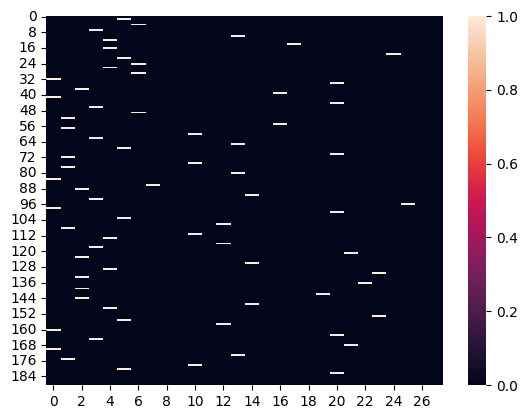

In [82]:
import seaborn as sns
sns.heatmap(X[3])

## Inspect design matrix

In [ ]:
# All columns and n1/n2 positions — check if interleaved or grouped
cols = dm_run.columns.tolist()
print(f'All columns: {cols}')
n1_positions = [i for i, c in enumerate(cols) if c.startswith('n1')]
n2_positions = [i for i, c in enumerate(cols) if c.startswith('n2')]
print(f'n1 positions: {n1_positions[:5]}')
print(f'n2 positions: {n2_positions[:5]}')

All columns: ['trial_001_n1', 'trial_001_n2', 'trial_002_n1', 'trial_002_n2', 'trial_003_n1', 'trial_003_n2', 'trial_004_n1', 'trial_004_n2', 'trial_005_n1', 'trial_005_n2', 'trial_006_n1', 'trial_006_n2', 'trial_007_n1', 'trial_007_n2', 'trial_008_n1', 'trial_008_n2', 'trial_009_n1', 'trial_009_n2', 'trial_010_n1', 'trial_010_n2', 'trial_011_n1', 'trial_011_n2', 'trial_012_n1', 'trial_012_n2', 'trial_013_n1', 'trial_013_n2', 'trial_014_n1', 'trial_014_n2', 'trial_015_n1', 'trial_015_n2', 'trial_016_n1', 'trial_016_n2', 'trial_017_n1', 'trial_017_n2', 'trial_018_n1', 'trial_018_n2', 'trial_019_n1', 'trial_019_n2', 'trial_020_n1', 'trial_020_n2', 'trial_021_n1', 'trial_021_n2', 'trial_022_n1', 'trial_022_n2', 'trial_023_n1', 'trial_023_n2', 'trial_024_n1', 'trial_024_n2', 'trial_025_n1', 'trial_025_n2', 'trial_026_n1', 'trial_026_n2', 'trial_027_n1', 'trial_027_n2', 'trial_028_n1', 'trial_028_n2', 'trial_029_n1', 'trial_029_n2', 'trial_030_n1', 'trial_030_n2', 'trial_031_n1', 'trial_031

In [ ]:
cols = dm_run.columns.tolist()
print(cols[:20])  # what does the full per-instance ordering look like?

['trial_001_n1', 'trial_001_n2', 'trial_002_n1', 'trial_002_n2', 'trial_003_n1', 'trial_003_n2', 'trial_004_n1', 'trial_004_n2', 'trial_005_n1', 'trial_005_n2', 'trial_006_n1', 'trial_006_n2', 'trial_007_n1', 'trial_007_n2', 'trial_008_n1', 'trial_008_n2', 'trial_009_n1', 'trial_009_n2', 'trial_010_n1', 'trial_010_n2']


## Run GLMsingle

In [18]:
derivatives = op.join(bids_folder, 'derivatives')

key = f'glm_stim.denoise'
key += '.coOccCV'  if coOccCV else ''
key += '.perstim' if perstim else ''

base_dir = op.join(derivatives, key, f'sub-{subject}', f'ses-{session}', 'func')
#os.makedirs(base_dir, exist_ok=True) # will be created by GLMsingle!

# set options for GLM-single
opt = dict()
opt['wantlibrary'] = 1 # set important fields for completeness (but these would be enabled by default)
opt['wantglmdenoise'] = 1
opt['wantfracridge'] = 1
opt['wantfileoutputs'] = [0, 0, 0, 1] # keep the relevant outputs in memory and also save them to the disk

glmsingle_obj = GLM_single(opt)
results_glmsingle = glmsingle_obj.fit(
    X,
    im_data,
    stim_duration,
    tr,
    outputdir=base_dir,
    figuredir=op.join(base_dir, 'GLMestimatesingletrialfigures') # would be written to cwd otherwise and could crash when multiple nodes use it at the same time
    )

*** DIAGNOSTICS ***:
There are 6 runs.
The number of conditions in this experiment is 28.
The stimulus duration corresponding to each trial is 0.60 seconds.
The TR (time between successive data points) is 2.83 seconds.
The number of trials in each run is: [72, 72, 72, 72, 72, 72].
The number of trials for each condition is: [36, 36, 36, 36, 36, 36, 26, 2, 3, 26, 4, 5, 12, 20, 4, 4, 14, 7, 14, 16, 18, 4, 5, 9, 17, 3, 1, 2].
For each condition, the number of runs in which it appears: [6, 6, 6, 6, 6, 6, 6, 2, 3, 5, 1, 3, 5, 6, 2, 4, 6, 5, 4, 6, 6, 3, 4, 5, 6, 2, 1, 2].
For each run, how much ending buffer do we have in seconds? [14.135, 14.135, 16.962, 16.962, 16.962, 16.962].
*** Saving design-related results to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-01/ses-1/func/DESIGNINFO.npy. ***
*** FITTING DIAGNOSTIC RUN-WISE FIR MODEL ***
*** Saving FIR results to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_s

chunks: 100%|██████████| 4/4 [02:41<00:00, 40.32s/it]


*** DETERMINING GLMDENOISE REGRESSORS ***

*** CROSS-VALIDATING DIFFERENT NUMBERS OF REGRESSORS ***



chunks: 100%|██████████| 4/4 [03:08<00:00, 47.04s/it]



*** FITTING TYPE-C MODEL (GLMDENOISE) ***



chunks: 100%|██████████| 4/4 [01:07<00:00, 16.95s/it]


*** FITTING TYPE-D MODEL (GLMDENOISE_RR) ***



chunks: 100%|██████████| 4/4 [12:19<00:00, 184.94s/it]



*** Saving results to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-01/ses-1/func/TYPED_FITHRF_GLMDENOISE_RR.npy. ***

*** All model types done ***

*** return model types in results ***



In [25]:
betas = results_glmsingle['typed']['betasmd']
print(f'Overall mean: {np.nanmean(betas):.4f}')
print(f'Overall std: {np.nanstd(betas):.4f}')
print(f'Min: {np.nanmin(betas):.4f}, Max: {np.nanmax(betas):.4f}')
print(f'Fraction of zeros: {np.nanmean((betas == 0)):.4f}')
print(f'Mean first half: {np.nanmean(betas[..., :216]):.4f}')
print(f'Mean second half: {np.nanmean(betas[..., 216:]):.4f}')

Overall mean: 0.4607
Overall std: 1094.3223
Min: -2765239.2500, Max: 3112055.7500
Fraction of zeros: 0.0000
Mean first half: 0.5721
Mean second half: 0.3492


In [21]:
print(f'Fraction of NaN: {np.isnan(betas).mean():.4f}')
print(f'NaN per beta volume:')
for i in range(betas.shape[-1]):
    frac = np.isnan(betas[..., i]).mean()
    if frac > 0:
        print(f'  beta {i}: {frac:.4f} NaN')

Fraction of NaN: 0.1701
NaN per beta volume:
  beta 0: 0.1701 NaN
  beta 1: 0.1701 NaN
  beta 2: 0.1701 NaN
  beta 3: 0.1701 NaN
  beta 4: 0.1701 NaN
  beta 5: 0.1701 NaN
  beta 6: 0.1701 NaN
  beta 7: 0.1701 NaN
  beta 8: 0.1701 NaN
  beta 9: 0.1701 NaN
  beta 10: 0.1701 NaN
  beta 11: 0.1701 NaN
  beta 12: 0.1701 NaN
  beta 13: 0.1701 NaN
  beta 14: 0.1701 NaN
  beta 15: 0.1701 NaN
  beta 16: 0.1701 NaN
  beta 17: 0.1701 NaN
  beta 18: 0.1701 NaN
  beta 19: 0.1701 NaN
  beta 20: 0.1701 NaN
  beta 21: 0.1701 NaN
  beta 22: 0.1701 NaN
  beta 23: 0.1701 NaN
  beta 24: 0.1701 NaN
  beta 25: 0.1701 NaN
  beta 26: 0.1701 NaN
  beta 27: 0.1701 NaN
  beta 28: 0.1701 NaN
  beta 29: 0.1701 NaN
  beta 30: 0.1701 NaN
  beta 31: 0.1701 NaN
  beta 32: 0.1701 NaN
  beta 33: 0.1701 NaN
  beta 34: 0.1701 NaN
  beta 35: 0.1701 NaN
  beta 36: 0.1701 NaN
  beta 37: 0.1701 NaN
  beta 38: 0.1701 NaN
  beta 39: 0.1701 NaN
  beta 40: 0.1701 NaN
  beta 41: 0.1701 NaN
  beta 42: 0.1701 NaN
  beta 43: 0.1701 N

In [22]:
for i, x in enumerate(X):
    cond = np.linalg.cond(x)
    print(f'Run {i+1} design matrix condition number: {cond:.2f}')

Run 1 design matrix condition number: inf
Run 2 design matrix condition number: inf
Run 3 design matrix condition number: inf
Run 4 design matrix condition number: inf
Run 5 design matrix condition number: inf
Run 6 design matrix condition number: inf


In [26]:
print(f'Voxels with |beta| > 1000: {(np.abs(betas) > 1000).sum()}')
print(f'Voxels with |beta| > 100: {(np.abs(betas) > 100).sum()}')
print(f'Voxels with |beta| > 10: {(np.abs(betas) > 10).sum()}')
# look at the distribution ignoring outliers
flat = betas[~np.isnan(betas)].flatten()
print(f'99th percentile: {np.percentile(flat, 99):.4f}')
print(f'1st percentile: {np.percentile(flat, 1):.4f}')

Voxels with |beta| > 1000: 99078
Voxels with |beta| > 100: 1845577
Voxels with |beta| > 10: 14744303
99th percentile: 131.8039
1st percentile: -123.5503


In [27]:
print(f'stim_duration: {stim_duration}')
print(f'TR: {TR}')
print(f'Design matrix unique values: {np.unique(X[0])}')  # should only be 0 and 1
print(f'Design matrix max: {X[0].max()}')

stim_duration: 0.6
TR: 2.827
Design matrix unique values: [0. 1.]
Design matrix max: 1.0


In [28]:
for i, x in enumerate(X):
    cond = np.linalg.cond(x)
    print(f'Run {i+1} condition number: {cond:.2f}')

Run 1 condition number: inf
Run 2 condition number: inf
Run 3 condition number: inf
Run 4 condition number: inf
Run 5 condition number: inf
Run 6 condition number: inf


In [29]:
# are the two columns perfectly correlated?
for i, x in enumerate(X):
    corr = np.corrcoef(x[:, 0], x[:, 1])[0, 1]
    print(f'Run {i+1} correlation between n1 and n2 columns: {corr:.4f}')

Run 1 correlation between n1 and n2 columns: -0.0328
Run 2 correlation between n1 and n2 columns: -0.0328
Run 3 correlation between n1 and n2 columns: -0.0328
Run 4 correlation between n1 and n2 columns: -0.0328
Run 5 correlation between n1 and n2 columns: -0.0328
Run 6 correlation between n1 and n2 columns: -0.0328


In [30]:
for i, x in enumerate(X):
    print(f'Run {i+1}:')
    print(f'  n1 column sum: {x[:, 0].sum()}')
    print(f'  n2 column sum: {x[:, 1].sum()}')
    print(f'  n1 nonzero: {(x[:, 0] != 0).sum()}')
    print(f'  n2 nonzero: {(x[:, 1] != 0).sum()}')
    print(f'  shape: {x.shape}')

Run 1:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)
Run 2:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)
Run 3:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)
Run 4:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)
Run 5:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)
Run 6:
  n1 column sum: 6.0
  n2 column sum: 6.0
  n1 nonzero: 6
  n2 nonzero: 6
  shape: (189, 28)


In [31]:
print(f'condition_to_idx: {condition_to_idx}')
print(f'Number of conditions: {len(condition_to_idx)}')

condition_to_idx: {'n1_10': 0, 'n1_14': 1, 'n1_20': 2, 'n1_28': 3, 'n1_5': 4, 'n1_7': 5, 'n2_10': 6, 'n2_11': 7, 'n2_13': 8, 'n2_14': 9, 'n2_15': 10, 'n2_19': 11, 'n2_2': 12, 'n2_20': 13, 'n2_21': 14, 'n2_27': 15, 'n2_28': 16, 'n2_3': 17, 'n2_4': 18, 'n2_40': 19, 'n2_5': 20, 'n2_56': 21, 'n2_57': 22, 'n2_6': 23, 'n2_7': 24, 'n2_79': 25, 'n2_8': 26, 'n2_9': 27}
Number of conditions: 28


In [32]:
for i, x in enumerate(X):
    rank = np.linalg.matrix_rank(x)
    print(f'Run {i+1}: rank={rank}, shape={x.shape}, expected rank={x.shape[1]}')

Run 1: rank=20, shape=(189, 28), expected rank=28
Run 2: rank=21, shape=(189, 28), expected rank=28
Run 3: rank=19, shape=(189, 28), expected rank=28
Run 4: rank=21, shape=(189, 28), expected rank=28
Run 5: rank=22, shape=(189, 28), expected rank=28
Run 6: rank=20, shape=(189, 28), expected rank=28


## Save results

In [20]:
# Save results: separate n1 and n2 betas
betas = results_glmsingle['typed']['betasmd']
print(f'Beta shape: {betas.shape}')

# Check column ordering before splitting — verify ::2 is safe to use
#cols = dm.columns.tolist()
#n1_indices = [i for i, c in enumerate(cols) if c == 'n1' or c.startswith('n1_')]
#n2_indices = [i for i, c in enumerate(cols) if c == 'n2' or c.startswith('n2_')]

all_trial_order = [t for to in trial_orders for t in to]
print(f'Total trials: {len(all_trial_order)}')  # should be 356 (178 n1 + 178 n2)

n1_indices = [i for i, t in enumerate(all_trial_order) if t.startswith('n1_')]
n2_indices = [i for i, t in enumerate(all_trial_order) if t.startswith('n2_')]

print(f'n1 indices (first 5): {n1_indices[:5]}')
print(f'n2 indices (first 5): {n2_indices[:5]}')
print(f'::2 matches n1_indices: {list(range(0, len(cols), 2))[:5] == n1_indices[:5]}')
print(f'1::2 matches n2_indices: {list(range(1, len(cols), 2))[:5] == n2_indices[:5]}')

Beta shape: (54, 66, 50, 432)
Total trials: 432
n1 indices (first 5): [0, 2, 4, 6, 8]
n2 indices (first 5): [1, 3, 5, 7, 9]


NameError: name 'cols' is not defined

In [85]:
if space == 'T1w':
    base = op.join(bids_folder, 'derivatives', 'fmriprep', f'sub-{subject}', f'ses-{session}', 'func')
    example_image = op.join(base, f'sub-{subject}_ses-{session}_task-{task}_run-1_space-{space}_desc-preproc_bold.nii.gz')
    betas = image.new_img_like(example_image, betas)

    # n1s
    betas_n1 = image.index_img(betas, slice(0, None, 2)) # slice(0, None, 2) where to start, where to end, step size
    betas_n1.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-{space}_desc-stims1_pe.nii.gz'))
    # n2s
    betas_n2 = image.index_img(betas, slice(1, None, 2)) # slice(0, None, 2) where to start, where to end, step size
    betas_n2.to_filename(op.join(base_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-{space}_desc-stims2_pe.nii.gz'))

elif space == 'fsaverage5':
    n_vertices_total, n_betas = betas.shape[:2]
    n_vertices_hemi = n_vertices_total // 2

    hemi_data = {
        'L': betas[:n_vertices_hemi],
        'R': betas[n_vertices_hemi:]
    }

    for hemi, hemi_betas in hemi_data.items():
        # Split N1 / N2 — using explicit indices (safe regardless of column ordering)
        hemi_betas_n1 = hemi_betas[:, n1_indices]
        hemi_betas_n2 = hemi_betas[:, n2_indices]

        for stim_n, hemi_b in zip([1, 2], [hemi_betas_n1, hemi_betas_n2]):
            darrays = [nib.gifti.GiftiDataArray(hemi_b[:, i].astype(np.float32)) for i in range(hemi_b.shape[1])]
            gii = nib.GiftiImage(darrays=darrays)
            fn = op.join(base_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-{space}_desc-stims{stim_n}_pe_hemi-{hemi}.gii')
            gii.to_filename(fn)
            print(f'Saved {fn}')

In [67]:
gii

In [1]:
# plot beta map to see whether it worked, also need to surface transform yay

import argparse
import os
import os.path as op
from numrisk.utils.data import Subject
from nilearn import surface
import nibabel as nb
import numpy as np

#from numrisk.fmri_analysis.encoding_model.fit_nprf import get_key_target_dir
from tqdm import tqdm
from nipype.interfaces.freesurfer import SurfaceTransform
from nilearn.maskers import NiftiMasker

subject = '02'
session =1
stims='1-2'
bids_folder='/mnt_04/ds-numrisk'

def transform_fsaverage(in_file, fs_hemi, source_subject, bids_folder, target_space = 'fsaverage5'):

        subjects_dir = op.join(bids_folder, 'derivatives', 'freesurfer')

        sxfm = SurfaceTransform(subjects_dir=subjects_dir)
        sxfm.inputs.source_file = in_file
        sxfm.inputs.out_file = in_file.replace('fsnative', target_space)
        sxfm.inputs.source_subject = source_subject
        sxfm.inputs.target_subject = target_space
        sxfm.inputs.hemi = fs_hemi

        r = sxfm.run()
        return r


def main(subject_id, session, stims, bids_folder):
    
    sub = Subject(subject_id, bids_folder=bids_folder)
    subject = f'{int(subject_id):02d}'

    stimsList = stims.split('-') if '-' in stims else [str(stims)]

    for stim in stimsList:

        key = f'glm_stim.denoise.coOccCV'
        target_dir = op.join('/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/', 'derivatives', key , f'sub-{subject}', f'ses-{session}', 'func')

        surfinfo = sub.get_surf_info_fs()

        print(f'Writing to {target_dir}')


        fn = op.join(target_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-T1w_desc-stims{stim}_pe.nii.gz')
        betas_vol = nb.load(fn)

        mask = sub.get_brain_mask()
        masker = NiftiMasker(mask_img=mask)
        betas = masker.fit_transform(betas_vol)
        betas_it= masker.inverse_transform(betas)

        for hemi in ['L', 'R']:
            samples = surface.vol_to_surf(betas_it, surfinfo[hemi]['outer'], inner_mesh=surfinfo[hemi]['inner'])
            fs_hemi = 'lh' if hemi == 'L' else 'rh'

            darrays = [nb.gifti.GiftiDataArray(samples[:, ix].astype('float32')) for ix in range(samples.shape[1])]
            im = nb.gifti.GiftiImage(darrays=darrays)

            for da in im.darrays:
                da.intent = nb.nifti1.intent_codes['NIFTI_INTENT_TIME_SERIES']

            target_fn = op.join(target_dir, f'sub-{subject}_ses-{session}_task-magjudge_space-fsnative_stim-{stim}_hemi-{hemi}.func.gii')
            nb.save(im, target_fn)

            transform_fsaverage(target_fn, fs_hemi, f'sub-{subject}', bids_folder, target_space = 'fsaverage5')

main(subject, session, stims, bids_folder)

260418-12:06:05,593 nipype.utils WARNING:
	 A newer version (1.11.0) of nipy/nipype is available. You are using 1.8.6
Writing to /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV/sub-02/ses-1/func
brain mask for run 1 does not exist, using run 2 instead
260418-12:07:01,226 nipype.interface INFO:
	 stderr 2026-04-18T12:07:01.226643:** DA[0] has coordsys with intent NIFTI_INTENT_TIME_SERIES (should be NIFTI_INTENT_POINTSET)
260418-12:07:01,235 nipype.interface INFO:
	 stderr 2026-04-18T12:07:01.235118:** DA[1] has coordsys with intent NIFTI_INTENT_TIME_SERIES (should be NIFTI_INTENT_POINTSET)
260418-12:07:01,243 nipype.interface INFO:
	 stderr 2026-04-18T12:07:01.243063:** DA[2] has coordsys with intent NIFTI_INTENT_TIME_SERIES (should be NIFTI_INTENT_POINTSET)
260418-12:07:01,250 nipype.interface INFO:
	 stderr 2026-04-18T12:07:01.250804:** DA[3] has coordsys with intent NIFTI_INTENT_TIME_SERIES (should be NIFTI_INTENT_POINTSET)
260418-12:07:

In [9]:
# plotting beta maps on the brain its ugly but should work

import nibabel as nib
import os
import numpy as np
from  nilearn.datasets import fetch_surf_fsaverage
import nilearn.plotting as nplt


home = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/glm_stim.denoise.coOccCV"

sub = '02'
ses = "ses-1"
func = "func"
stims = ['stims1', 'stims2']
hemis = ['L', 'R']

# file_path = os.path.join(home, f'{sub}', f'{ses}', f'{func}', f"{sub}_{ses}_task-magjudge_space-fsaverage5_desc-{stims}_pe_hemi-{hemis}.gii")

# # load one file
# gii = nib.load(file_path)

# print(gii)  # basic info

# # number of data arrays
# print("Number of darrays:", len(gii.darrays))

# # inspect the first data array
# data = gii.darrays[0].data
# print("Data shape:", data.shape)
# print("Value range:", np.min(data), "to", np.max(data))
# print("Data:", data)

home_glm = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/"

# Base folders for each stimulus
stim_folders = {
    1: os.path.join(home_glm, "glm_stim.denoise.coOccCV"),
    2: os.path.join(home_glm, "glm_stim.denoise.coOccCV")
}

ses = "1"
func = "func"


for stim, stim_dir in stim_folders.items():
    subList = [sub]
    # List all subjects in this stimulus folder
    for sub in subList:

        # Output folder
        output_folder = os.path.join(home_glm, "average_act.glm", "mean_maps.glm", f"stim-{stim}", f"sub-{sub}")
        os.makedirs(output_folder, exist_ok=True)
        
        print(f"Processing sub-{sub}...")
        data_path = os.path.join(stim_dir, f'sub-{sub}', f'ses-{ses}', func)
        
        for hemi in ['L', 'R']:
            print(f" Stimulus {stim}, Hemisphere {hemi}")
            gii_file = os.path.join(data_path, f"sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-{stim}_hemi-{hemi}.{func}.gii")
        
            if not os.path.exists(gii_file):
                print(f"  File not found: {gii_file}") 
                continue
            
            # Load GIFTI
            gii = nib.load(gii_file)


            # Stack all darrays into a 2D array (n_vertices, n_trials)
            all_data = np.stack([darray.data for darray in gii.darrays], axis=1)
            
            # Average across trials
            avg_data = np.mean(all_data, axis=1).astype(np.float32)

            out_file = os.path.join(output_folder, f"sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-{stim}_hemi-{hemi}_average.{func}.gii")


            # Save averaged GIFTI
            avg_gii = nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(avg_data)])
            nib.save(avg_gii, out_file)
            print(f"  Saved averaged map for stimulus {stim} to {out_file}")



Processing sub-02...
 Stimulus 1, Hemisphere L
  Saved averaged map for stimulus 1 to /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm/stim-1/sub-02/sub-02_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-L_average.func.gii
 Stimulus 1, Hemisphere R
  Saved averaged map for stimulus 1 to /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm/stim-1/sub-02/sub-02_ses-1_task-magjudge_space-fsaverage5_stim-1_hemi-R_average.func.gii
Processing sub-02...
 Stimulus 2, Hemisphere L
  Saved averaged map for stimulus 2 to /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm/stim-2/sub-02/sub-02_ses-1_task-magjudge_space-fsaverage5_stim-2_hemi-L_average.func.gii
 Stimulus 2, Hemisphere R
  Saved averaged map for stimulus 2 to /mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm/stim-2/sub-02/sub-02_ses-1_task

In [106]:
all_data.shape

(10242, 216)

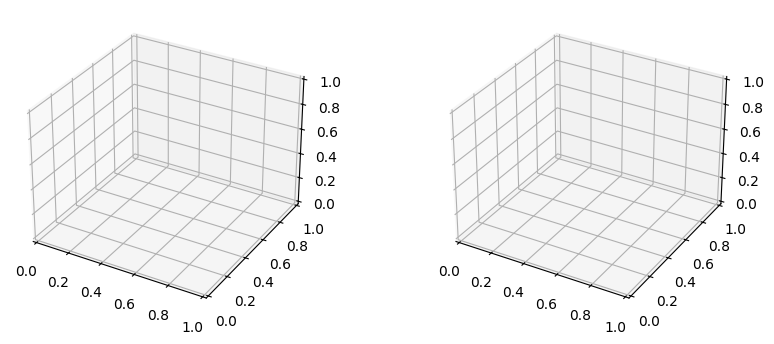

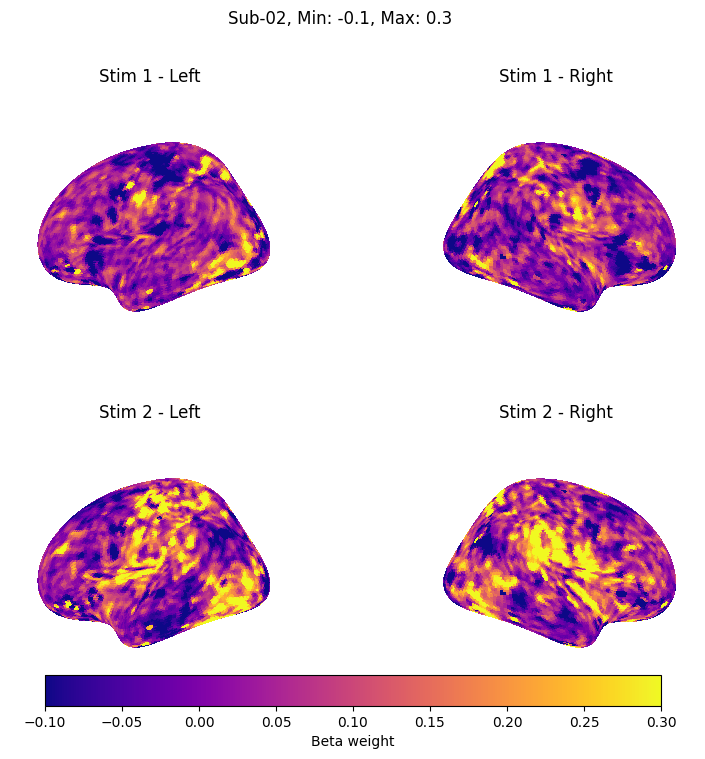

In [10]:
stims = [1, 2]


for stim in stims:
    output_folder = f'/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-numrisk/derivatives/average_act.glm/mean_maps.glm/stim-{stim}/sub-{sub}'

    if stim == 1:
        gm_stim1_lh = nib.load(op.join(output_folder, f'sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-1_hemi-L_average.func.gii'))
        gm_stim1_rh = nib.load(op.join(output_folder, f'sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-1_hemi-R_average.func.gii'))

    if stim == 2:
        gm_stim2_lh = nib.load(op.join(output_folder, f'sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-2_hemi-L_average.func.gii'))
        gm_stim2_rh = nib.load(op.join(output_folder, f'sub-{sub}_ses-{ses}_task-magjudge_space-fsaverage5_stim-2_hemi-R_average.func.gii'))

gm_stim1_lh = gm_stim1_lh.darrays[0].data
gm_stim1_rh = gm_stim1_rh.darrays[0].data
gm_stim2_lh = gm_stim2_lh.darrays[0].data
gm_stim2_rh = gm_stim2_rh.darrays[0].data

fsaverage = fetch_surf_fsaverage() # default 5

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, subplot_kw=dict(projection="3d"), figsize=(10, 4))

# color gradient
vmin, vmax = -0.1, 0.3
#vmin = data_stim2.min()
#vmax = data_stim1.max()

# 2 rows × 2 columns
fig, axes = plt.subplots(2, 2, figsize=(10, 8), subplot_kw=dict(projection='3d'))

# Stimulus 1
nplt.plot_surf_stat_map(
    fsaverage.infl_left, gm_stim1_lh, hemi='left',
    view='lateral', bg_map=fsaverage.sulc_left, cmap='plasma',
    colorbar=False, vmin=vmin, vmax=vmax, axes=axes[0,0]
)
axes[0,0].set(title='Stim 1 - Left')

nplt.plot_surf_stat_map(
    fsaverage.infl_right, gm_stim1_rh, hemi='right',
    view='lateral', bg_map=fsaverage.sulc_right, cmap='plasma',
    colorbar=False, vmin=vmin, vmax=vmax, axes=axes[0,1]
)
axes[0,1].set(title='Stim 1 - Right')

# Stimulus 2
nplt.plot_surf_stat_map(
    fsaverage.infl_left, gm_stim2_lh, hemi='left',
    view='lateral', bg_map=fsaverage.sulc_left, cmap='plasma',
    colorbar=False, vmin=vmin, vmax=vmax, axes=axes[1,0]
)
axes[1,0].set(title='Stim 2 - Left')

nplt.plot_surf_stat_map(
    fsaverage.infl_right, gm_stim2_rh, hemi='right',
    view='lateral', bg_map=fsaverage.sulc_right, cmap='plasma',
    colorbar=False, vmin=vmin, vmax=vmax, axes=axes[1,1]
)
axes[1,1].set(title='Stim 2 - Right')

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05, label='Beta weight')

fig.suptitle(f'Sub-{sub}, Min: {vmin}, Max: {vmax}')


plt.subplots_adjust(wspace=0.1, hspace=0.2)
plt.show()

In [68]:
import inspect
from glmsingle.glmsingle import GLM_single
print(inspect.signature(GLM_single.fit))


(self, design, data, stimdur, tr, outputdir=None, figuredir=None)
